In [21]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [24]:
# 1. Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

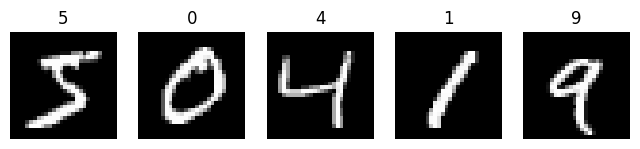

In [23]:
# 2. Display 5 sample images
plt.figure(figsize=(8, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")
plt.show()



In [25]:
# 3. Normalize data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

In [26]:
# 4. Build neural network
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [27]:
# 5. Compile model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [28]:
# 6. Train model
history = model.fit(
    x_train, y_train,
    epochs=5,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9226 - loss: 0.2688 - val_accuracy: 0.9677 - val_loss: 0.1268
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9644 - loss: 0.1191 - val_accuracy: 0.9707 - val_loss: 0.0954
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9755 - loss: 0.0821 - val_accuracy: 0.9740 - val_loss: 0.0938
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9812 - loss: 0.0610 - val_accuracy: 0.9762 - val_loss: 0.0818
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9855 - loss: 0.0482 - val_accuracy: 0.9775 - val_loss: 0.0766


In [29]:
# 7. Test accuracy
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print("Test Accuracy:", accuracy * 100, "%")


Test Accuracy: 97.49000072479248 %


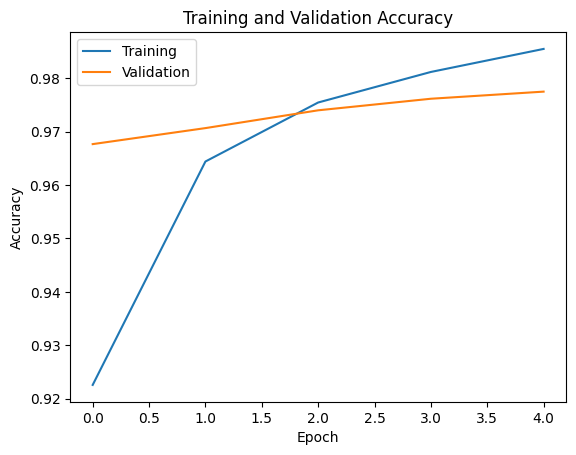

In [30]:
# 8. Accuracy graph
plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


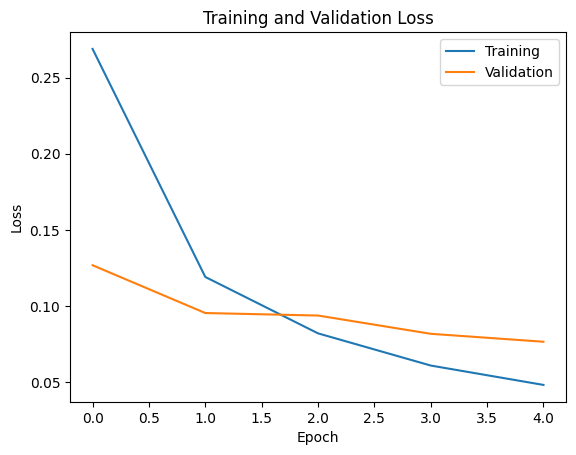

In [31]:
# 9. Loss graph
plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


Actual Labels:    [7 2 1 0 4]
Predicted Labels: [7 2 1 0 4]


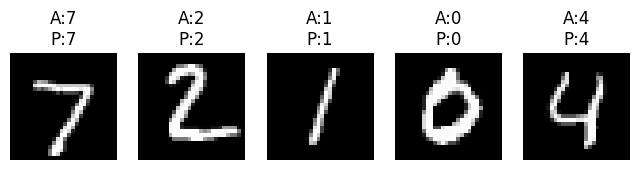

In [32]:
# 10. Predict 5 test images
predicted = np.argmax(model.predict(x_test[:5], verbose=0), axis=1)

print("Actual Labels:   ", y_test[:5])
print("Predicted Labels:", predicted)

# Display predictions
plt.figure(figsize=(8, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title("A:" + str(y_test[i]) + "\nP:" + str(predicted[i]))
    plt.axis("off")
plt.show()

In [33]:
# 11. Experiment: Dropout
model2 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation="softmax")
])

model2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model2.fit(x_train, y_train, epochs=5, validation_split=0.1)

_, dropout_accuracy = model2.evaluate(x_test, y_test, verbose=0)

print("Original Model Accuracy:", accuracy * 100, "%")
print("Dropout Model Accuracy:", dropout_accuracy * 100, "%")

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9100 - loss: 0.3118 - val_accuracy: 0.9642 - val_loss: 0.1241
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9556 - loss: 0.1492 - val_accuracy: 0.9732 - val_loss: 0.0997
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9663 - loss: 0.1112 - val_accuracy: 0.9788 - val_loss: 0.0768
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9731 - loss: 0.0888 - val_accuracy: 0.9768 - val_loss: 0.0790
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9757 - loss: 0.0794 - val_accuracy: 0.9782 - val_loss: 0.0784
Original Model Accuracy: 97.49000072479248 %
Dropout Model Accuracy: 97.46000170707703 %
